# Bangkok Airbnb Cohort Analysis

Cohort analysis across two dimensions:
1. **Neighbourhood** — which area generates the most accumulated revenue near end of 2025
2. **Superhost status** — whether being a Superhost correlates with higher review volume

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from scipy import stats

df_raw = pd.read_csv("data/active_listings.csv")

# One row per unique listing — drop repeated rows caused by the reviews join
listings = df_raw.drop_duplicates(subset="listing_id").copy()

print(f"Unique listings: {listings['listing_id'].nunique():,}")
print(f"Unique neighbourhoods: {listings['neighbourhood_cleansed'].nunique()}")
print(f"Scrape date range: {listings['last_scraped'].dropna().unique()[:3]}")

Unique listings: 14,903
Unique neighbourhoods: 48
Scrape date range: ['2025-09-27' '0.0' '2025-09-26']


---

# Cohort Analysis 1 — Revenue by Neighbourhood

Group listings by `neighbourhood_cleansed` and sum `estimated_revenue_l365d` (trailing 365-day estimated revenue, scraped September 2025) to compare accumulated revenue near the end of 2025.

## Step 1 — Build Neighbourhood Cohorts

In [2]:
# Drop listings with no revenue estimate
revenue_df = listings.dropna(subset=["neighbourhood_cleansed", "estimated_revenue_l365d"]).copy()

# Cohort = neighbourhood group
cohort_revenue = (
    revenue_df
    .groupby("neighbourhood_cleansed", as_index=False)
    .agg(
        total_revenue=("estimated_revenue_l365d", "sum"),
        listing_count=("listing_id", "count"),
        avg_revenue_per_listing=("estimated_revenue_l365d", "mean"),
    )
    .sort_values("total_revenue", ascending=False)
    .reset_index(drop=True)
)

cohort_revenue["total_revenue_M"] = cohort_revenue["total_revenue"] / 1_000_000  # millions THB

print(cohort_revenue[["neighbourhood_cleansed", "listing_count", "total_revenue_M", "avg_revenue_per_listing"]].to_string(index=False))

neighbourhood_cleansed  listing_count  total_revenue_M  avg_revenue_per_listing
               Vadhana           2439       601.215794            246500.940549
           Khlong Toei           2048       446.754269            218141.732910
           Ratchathewi            752       175.049666            232778.811170
           Huai Khwang           1247       166.985696            133909.940658
              Bang Rak            574       152.913996            266400.689895
           Parthum Wan            389       139.604149            358879.560411
           Phra Nakhon            513       121.621424            237078.799220
                Sathon            733       107.216191            146270.383356
          Phra Khanong            667        84.702463            126990.199400
            Khlong San            359        58.144237            161961.662953
            Chatu Chak            425        56.307609            132488.491765
            Phaya Thai            278   

## Step 2 — Accumulated Revenue by Neighbourhood Cohort (End of 2025)

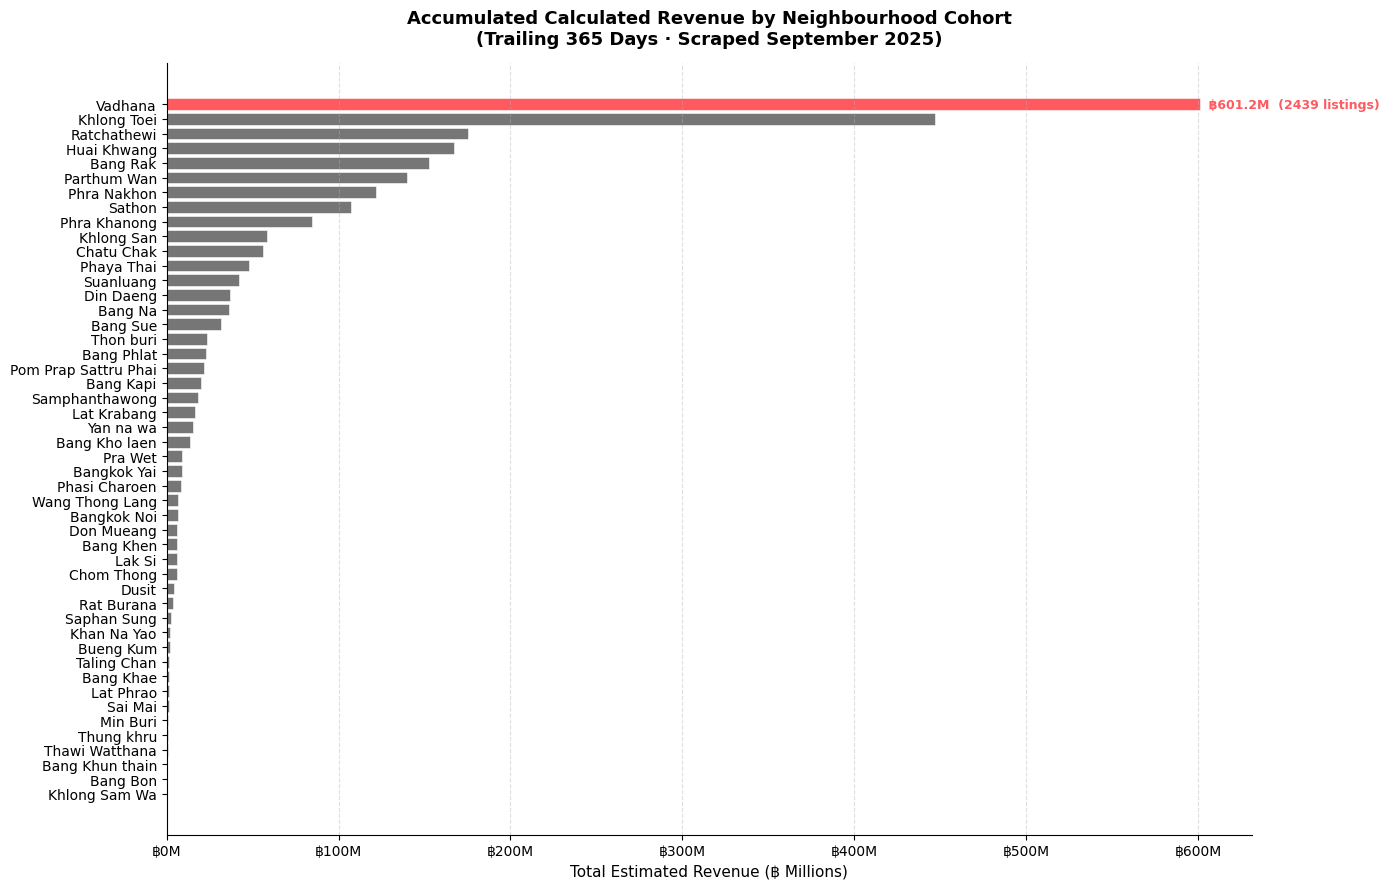


Top neighbourhood: Vadhana  —  ฿601.2M total


In [3]:
fig, ax = plt.subplots(figsize=(14, 9))

colors = ["#FF5A5F" if i == 0 else "#767676" for i in range(len(cohort_revenue))]

ax.barh(
    cohort_revenue["neighbourhood_cleansed"],
    cohort_revenue["total_revenue_M"],
    color=colors,
    edgecolor="white",
    linewidth=0.4,
)

top = cohort_revenue.iloc[0]
ax.annotate(
    f"  \u0e3f{top['total_revenue_M']:.1f}M  ({int(top['listing_count'])} listings)",
    xy=(top["total_revenue_M"], 0),
    fontsize=9, color="#FF5A5F", fontweight="bold", va="center",
)

ax.invert_yaxis()
ax.set_xlabel("Total Estimated Revenue (\u0e3f Millions)", fontsize=11)
ax.set_title(
    "Accumulated Calculated Revenue by Neighbourhood Cohort\n"
    "(Trailing 365 Days \u00b7 Scraped September 2025)",
    fontsize=13, fontweight="bold", pad=14,
)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"\u0e3f{x:.0f}M"))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("neighbourhood_cohort_revenue.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nTop neighbourhood: {top['neighbourhood_cleansed']}  \u2014  \u0e3f{top['total_revenue_M']:.1f}M total")

---

# Cohort Analysis 2 — Superhost Status vs. Number of Reviews

Split listings into two cohorts:
- **Superhost** (`host_is_superhost = t`)
- **Regular host** (`host_is_superhost = f`)

Then compare review volume across four timeframes to assess whether Superhost status is associated with a higher number of reviews.

## Step 1 — Build Superhost Cohorts & Summary Statistics

In [4]:
review_cols = [
    "number_of_reviews",
    "number_of_reviews_ltm",
    "number_of_reviews_l30d",
    "reviews_per_month",
]

# Cohort split — keep only rows with a clear superhost label
cohort_df = listings[listings["host_is_superhost"].isin(["t", "f"])].copy()
cohort_df["cohort"] = cohort_df["host_is_superhost"].map({"t": "Superhost", "f": "Regular host"})

print("Cohort sizes:")
print(cohort_df["cohort"].value_counts().to_string())

# Summary stats per cohort
summary = (
    cohort_df.groupby("cohort")[review_cols]
    .agg(["mean", "median", "std"])
    .round(2)
)
print("\nSummary statistics:")
print(summary.to_string())

# Mann-Whitney U test (non-parametric — review counts are heavily skewed)
super_reviews   = cohort_df.loc[cohort_df["cohort"] == "Superhost",    "number_of_reviews"]
regular_reviews = cohort_df.loc[cohort_df["cohort"] == "Regular host", "number_of_reviews"]
u_stat, p_value = stats.mannwhitneyu(super_reviews, regular_reviews, alternative="greater")
print(f"\nMann-Whitney U test (Superhost > Regular host, all-time reviews):")
print(f"  U = {u_stat:,.0f},  p-value = {p_value:.2e}  {'*** significant' if p_value < 0.05 else 'not significant'}")

Cohort sizes:
cohort
Regular host    7377
Superhost       6418

Summary statistics:
             number_of_reviews               number_of_reviews_ltm               number_of_reviews_l30d              reviews_per_month             
                          mean median    std                  mean median    std                   mean median   std              mean median   std
cohort                                                                                                                                             
Regular host             28.75    9.0  54.36                  8.21    3.0  16.11                   0.45    0.0  1.29              0.94   0.55  1.34
Superhost                44.11   18.0  81.48                 14.23    7.0  19.91                   0.85    0.0  1.57              1.40   0.90  1.52

Mann-Whitney U test (Superhost > Regular host, all-time reviews):
  U = 28,911,954,  p-value = 3.27e-112  *** significant


## Step 2 — Visualisation: Review Volume by Cohort

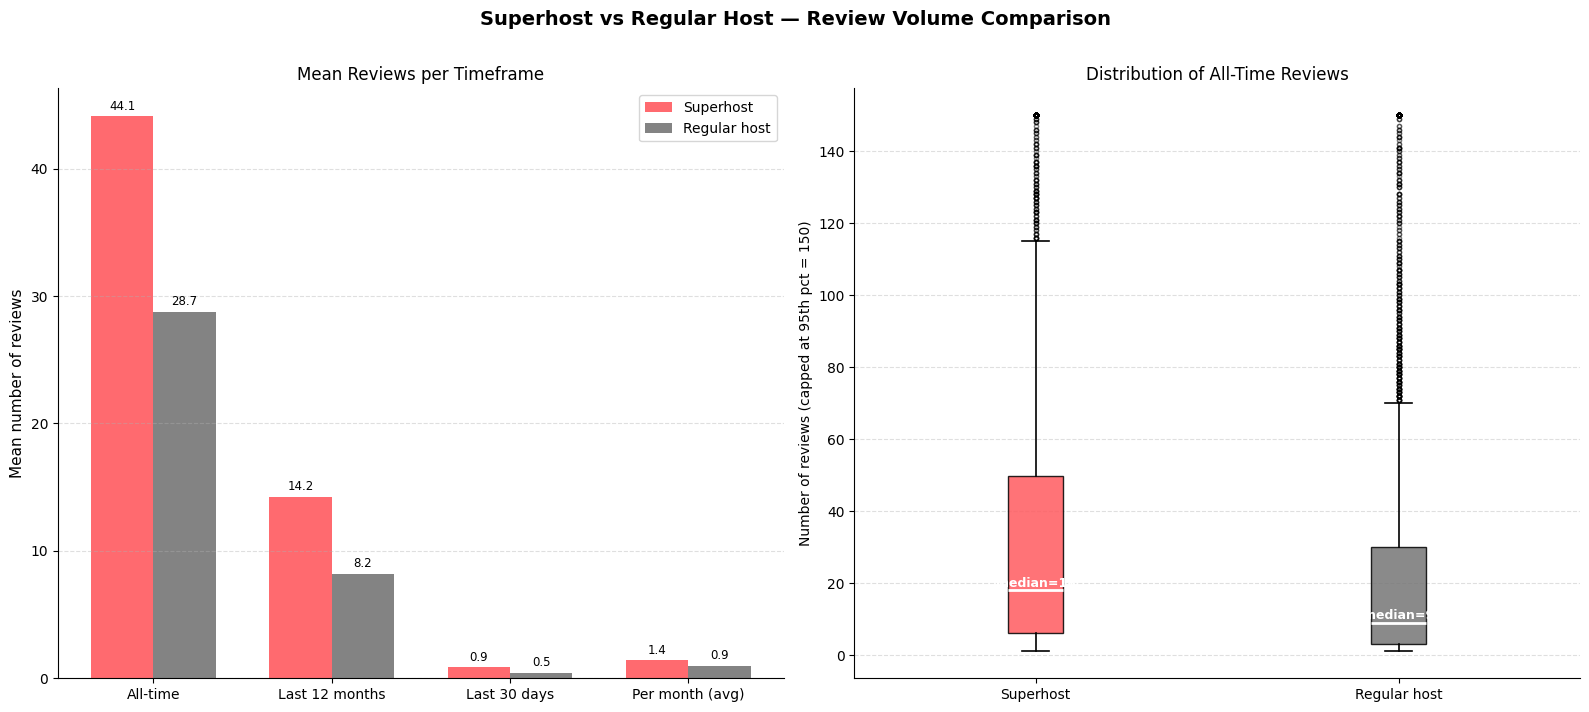

In [5]:
COLORS = {"Superhost": "#FF5A5F", "Regular host": "#767676"}
TIMEFRAMES = {
    "number_of_reviews":      "All-time",
    "number_of_reviews_ltm":  "Last 12 months",
    "number_of_reviews_l30d": "Last 30 days",
    "reviews_per_month":      "Per month (avg)",
}

fig, (ax_bar, ax_box) = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    "Superhost vs Regular Host \u2014 Review Volume Comparison",
    fontsize=14, fontweight="bold", y=1.01,
)

# Left: grouped bar chart of mean reviews per timeframe
means = cohort_df.groupby("cohort")[list(TIMEFRAMES.keys())].mean()
x = np.arange(len(TIMEFRAMES))
width = 0.35

for i, cohort in enumerate(["Superhost", "Regular host"]):
    vals = [means.loc[cohort, col] for col in TIMEFRAMES]
    rects = ax_bar.bar(x + i * width, vals, width, label=cohort, color=COLORS[cohort], alpha=0.9)
    for rect, v in zip(rects, vals):
        ax_bar.text(
            rect.get_x() + rect.get_width() / 2,
            rect.get_height() + 0.3,
            f"{v:.1f}",
            ha="center", va="bottom", fontsize=8.5,
        )

ax_bar.set_xticks(x + width / 2)
ax_bar.set_xticklabels(TIMEFRAMES.values(), fontsize=10)
ax_bar.set_ylabel("Mean number of reviews", fontsize=11)
ax_bar.set_title("Mean Reviews per Timeframe", fontsize=12)
ax_bar.legend(fontsize=10)
ax_bar.spines[["top", "right"]].set_visible(False)
ax_bar.grid(axis="y", linestyle="--", alpha=0.4)

# Right: box plot of all-time reviews (capped at 95th pct for readability)
cap = cohort_df["number_of_reviews"].quantile(0.95)
plot_data = [
    cohort_df.loc[cohort_df["cohort"] == c, "number_of_reviews"].clip(upper=cap)
    for c in ["Superhost", "Regular host"]
]
bp = ax_box.boxplot(
    plot_data,
    tick_labels=["Superhost", "Regular host"],
    patch_artist=True,
    medianprops=dict(color="white", linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker="o", markersize=3, alpha=0.3),
)
for patch, cohort in zip(bp["boxes"], ["Superhost", "Regular host"]):
    patch.set_facecolor(COLORS[cohort])
    patch.set_alpha(0.85)

ax_box.set_ylabel(f"Number of reviews (capped at 95th pct = {cap:.0f})", fontsize=10)
ax_box.set_title("Distribution of All-Time Reviews", fontsize=12)
ax_box.spines[["top", "right"]].set_visible(False)
ax_box.grid(axis="y", linestyle="--", alpha=0.4)

for i, cohort in enumerate(["Superhost", "Regular host"]):
    med = cohort_df.loc[cohort_df["cohort"] == cohort, "number_of_reviews"].median()
    ax_box.text(i + 1, med + 1, f"median={med:.0f}", ha="center", fontsize=9, color="white", fontweight="bold")

plt.tight_layout()
plt.savefig("superhost_review_cohort.png", dpi=150, bbox_inches="tight")
plt.show()


# Retention Analysis — Recency of Activity (Churn Risk Proxy)
Retention is measured by **how recently** a listing received a review, not just how long it has been on the platform. A long-inactive listing that has stopped receiving reviews is a signal of quiet churn.

**Method:** Calculate the gap (in days) between each listing's `last_review` date and the dataset scrape date (2025-09-27), then assign a churn risk tier:
| Tier | Gap | Interpretation |
|---|---|---|
| Active | 0–30 days | Recently reviewed, healthy activity |
| Cooling | 31–60 days | Slight lag, low risk |
| At Risk | 61–120 days | Moderate churn risk |
| High Risk | 121+ days | 4+ months without a review — likely churned or dormant |"
   

## Step 1 — Compute Days Since Last Review & Assign Churn Risk Tiers

In [7]:
SCRAPE_DATE = pd.Timestamp("2025-09-27")
retention = listings.copy()
retention["last_review"] = pd.to_datetime(retention["last_review"], errors="coerce")
retention["days_since_review"] = (SCRAPE_DATE - retention["last_review"]).dt.days
# One listing has no review at all — treat as highest risk
retention["days_since_review"] = retention["days_since_review"].fillna(9999)
# Assign churn risk tiers
def churn_tier(days):
    if days <= 30:   
        return "Active"
    if days <= 60:   
        return "Cooling"
    if days <= 120:  
        return "At Risk"
    return "High Risk"
retention["churn_risk"] = retention["days_since_review"].apply(churn_tier)
TIER_ORDER = ["Active", "Cooling", "At Risk", "High Risk"]
TIER_COLORS = {
    "Active":    "#00A699",
    "Cooling":   "#FFB400",
    "At Risk":   "#FF5A5F",
    "High Risk": "#767676",
    }
# Summary table
summary = (
    retention.groupby("churn_risk", observed=True)
    .agg(listing_count=("listing_id", "count"),
         median_days=("days_since_review", "median"),
         mean_days=("days_since_review", "mean"))
         .reindex(TIER_ORDER)
         .assign(pct=lambda df: (df["listing_count"] / df["listing_count"].sum() * 100).round(1))
         )
summary["mean_days"] = summary["mean_days"].round(1)
print(summary.to_string())

            listing_count  median_days  mean_days   pct
churn_risk                                             
Active               5005         16.0       15.6  33.6
Cooling              2729         42.0       43.4  18.3
At Risk              2192         86.0       87.1  14.7
High Risk            4977        216.0      219.0  33.4


## Step 2 — Visualisation: Churn Risk Distribution

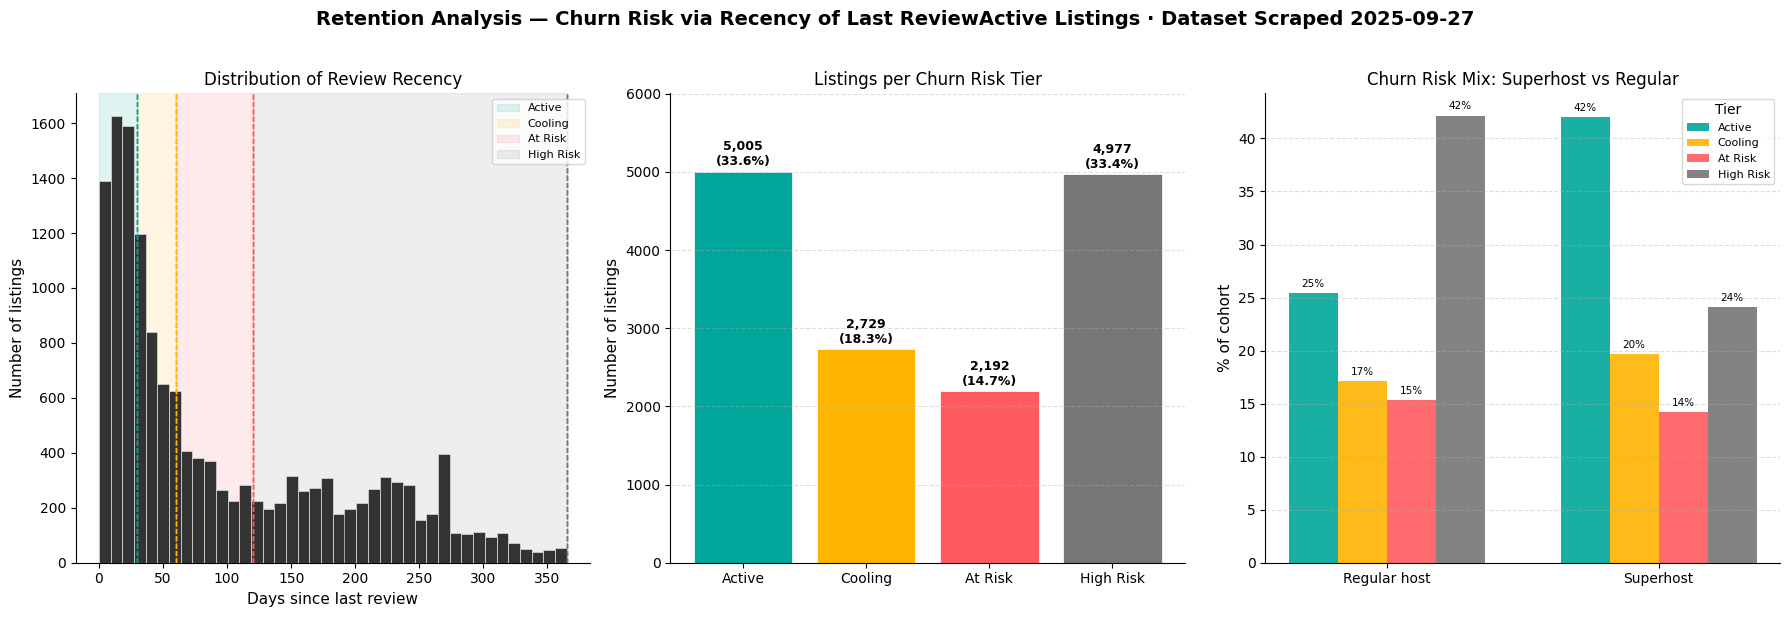

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "Retention Analysis — Churn Risk via Recency of Last Review"
        "Active Listings · Dataset Scraped 2025-09-27",
        fontsize=14, fontweight="bold", y=1.02,
        )
# ── Panel 1: histogram of days_since_review with risk zone bands ───────────
ax1 = axes[0]
plot_days = retention.loc[retention["days_since_review"] < 9999, "days_since_review"]
zone_spans = [(0, 30, "Active", "#00A699"), (30, 60, "Cooling", "#FFB400"),
              (60, 120, "At Risk", "#FF5A5F"), (120, 365, "High Risk", "#767676")]
for x0, x1, label, color in zone_spans:
    ax1.axvspan(x0, x1, alpha=0.12, color=color, label=label)
    ax1.hist(plot_days, bins=40, color="#333333", edgecolor="white", linewidth=0.4, zorder=3)
    for x0, x1, _, color in zone_spans:
        ax1.axvline(x1, color=color, linewidth=1, linestyle="--", alpha=0.7, zorder=4)
        ax1.set_xlabel("Days since last review", fontsize=11)
        ax1.set_ylabel("Number of listings", fontsize=11)
        ax1.set_title("Distribution of Review Recency", fontsize=12)
        ax1.legend(fontsize=8, loc="upper right")
        ax1.spines[["top", "right"]].set_visible(False)
# ── Panel 2: bar chart — listing count per churn risk tier ─────────────────
ax2 = axes[1]
counts = summary["listing_count"].values
bar_colors = [TIER_COLORS[t] for t in TIER_ORDER]
bars = ax2.bar(TIER_ORDER, counts, color=bar_colors, edgecolor="white", linewidth=0.5)

for bar, count, pct in zip(bars, counts, summary["pct"]):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 40,
        f"{count:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )
ax2.set_ylabel("Number of listings", fontsize=11)
ax2.set_title("Listings per Churn Risk Tier", fontsize=12)
ax2.spines[["top", "right"]].set_visible(False)
ax2.grid(axis="y", linestyle="--", alpha=0.4)
ax2.set_ylim(0, counts.max() * 1.2)
# ── Panel 3: churn risk split by superhost status ──────────────────────────
ax3 = axes[2]
cross = (
    retention[retention["host_is_superhost"].isin(["t", "f"])]
    .groupby(["host_is_superhost", "churn_risk"], observed=True)
    .size()
    .unstack("churn_risk")
    .reindex(columns=TIER_ORDER)
    .rename(index={"t": "Superhost", "f": "Regular host"})
    )
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
x = np.arange(len(cross_pct))
width = 0.18
for i, tier in enumerate(TIER_ORDER):
    bars = ax3.bar(
        x + i * width,
        cross_pct[tier],
        width,
        label=tier,
        color=TIER_COLORS[tier],
        alpha=0.9,
        )
    for bar, v in zip(bars, cross_pct[tier]):
        if v > 4:
            ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
            f"{v:.0f}%", ha="center", va="bottom", fontsize=7.5)
            ax3.set_xticks(x + width * 1.5)
            ax3.set_xticklabels(cross_pct.index, fontsize=10)
            ax3.set_ylabel("% of cohort", fontsize=11)
            ax3.set_title("Churn Risk Mix: Superhost vs Regular", fontsize=12)
            ax3.legend(fontsize=8, title="Tier")
            ax3.spines[["top", "right"]].set_visible(False)
            ax3.grid(axis="y", linestyle="--", alpha=0.4)
            
plt.tight_layout()
plt.savefig("churn_risk_retention.png", dpi=150, bbox_inches="tight")
plt.show()

- Left: Histogram of days_since_review with colour-coded risk zone bands and dashed threshold lines

- Centre: Bar chart of listing counts per tier with count + percentage labels

- Right: Cross-tab showing churn risk mix broken down by Superhost vs Regular host — the most striking finding: ***42% of regular hosts are High Risk vs only 24% of Superhosts***, reinforcing that Superhost status correlates with stronger ongoing engagement.
